In [1]:
import pandas as pd
import xgboost as xgb
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # Nécessaire pour activer l'IterativeImputer
from sklearn.impute import IterativeImputer
import missingno as msno
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import IsolationForest

In [2]:
def load_data(name):
    df = pd.read_csv(name)
    return df

In [3]:
def data_search_isna(df):
    return df.isna().sum()

In [4]:
def data_remplace_Mode_isna(df):
    # Remplacement par la valeur la plus fréquente (Mode)
    for col in ["State", "BankState", "NewExist", "LowDoc","RevLineCr"]:
        df[col] = df[col].fillna(df[col].mode()[0])

In [5]:
def data_remplace_MIS_STATUS(df):
    for col in ["FranchiseCode", "RevLineCr", "LowDoc"]:
        df["MIS_Status"] = df.groupby(col)["MIS_Status"].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "PIF"))


In [6]:
def data_Correlation_mis_status(df_num):

    # Calculer la matrice de corrélation
    corr_matrix = df_num.corr()

    # Afficher la heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matrice de corrélation")
    plt.show()


In [7]:
def calcul_Correlation_cat(df, cat_vars):
    df_=df[cat_vars+["MIS_Status"]].copy()
    # Stocker les résultats
    correlations = {}

    for col in cat_vars:
        contingency_table = pd.crosstab(df[col], df["MIS_Status"])
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        correlations[col] = p_value  # Plus le p-value est petit, plus la relation est forte

    # Trier par ordre croissant de p-value (plus c'est bas, plus c'est corrélé)
    sorted_correlations = sorted(correlations.items(), key=lambda x: x[1])

    # Afficher les résultats
    for col, p_val in sorted_correlations:
        print(f"Variable: {col} - p-value: {p_val}")

In [8]:
def calcul_Correlation_Pearson(df, cat_vars):

    # Encoder MIS_Status en 0 et 1
    df["MIS_Status_Encoded"] = df["MIS_Status"]#.apply(lambda x: 1 if x == "PIF" else 0)

    # Encoder toutes les variables catégorielles
    encoder = LabelEncoder()
    encoded_cat_vars = {}

    for col in cat_vars:
        df[col] = df[col].astype(str)  # Convertir en string
        df[col + "_Encoded"] = encoder.fit_transform(df[col])
        encoded_cat_vars[col] = col + "_Encoded"

    # Calculer la corrélation de Pearson
    correlation_matrix = df[["MIS_Status_Encoded"] + list(encoded_cat_vars.values())].corr()

    # Extraire les corrélations avec MIS_Status
    mis_status_corr = correlation_matrix["MIS_Status_Encoded"].drop("MIS_Status_Encoded")

    # Trier et afficher les résultats
    print(mis_status_corr.abs().sort_values(ascending=False))

In [9]:
df=load_data("preparation_data.csv")

In [10]:
df.head(50)

,Term,FranchiseCode,State,BankState,NAICS_2,NoEmp,NewExist,RetainedJob,CreateJob,UrbanRural,RevLineCr,ApprovalFY,DisbursementGross,GrAppv,LowDoc,MIS_Status
0,84,1,IN,OH,45,4,2.0,0,0,0,0.0,1997,60000.0,60000.0,1.0,1.0
1,60,1,IN,IN,72,2,2.0,0,0,0,0.0,1997,40000.0,40000.0,1.0,1.0
2,180,1,IN,IN,62,7,1.0,0,0,0,0.0,1997,287000.0,287000.0,0.0,1.0
3,60,1,OK,OK,0,2,1.0,0,0,0,0.0,1997,35000.0,35000.0,1.0,1.0
4,240,1,FL,FL,0,14,1.0,7,7,0,0.0,1997,229000.0,229000.0,0.0,1.0
5,120,1,CT,DE,33,19,1.0,0,0,0,0.0,1997,517000.0,517000.0,0.0,1.0
6,45,0,NJ,SD,0,45,2.0,0,0,0,0.0,1980,600000.0,600000.0,0.0,0.0
7,84,1,FL,AL,81,1,2.0,0,0,0,0.0,1997,45000.0,45000.0,1.0,1.0
8,297,1,FL,FL,72,2,2.0,0,0,0,0.0,1997,305000.0,305000.0,0.0,1.0
9,84,1,CT,CT,0,3,2.0,0,0,0,0.0,1997,70000.0,70000.0,1.0,1.0


In [11]:

# Création des nouvelles variables
recession_years = [2008, 2009, 2020]  # Exemples d'années de récession
df['RecessionPeriod'] = df['ApprovalFY'].apply(lambda x: 1 if x in recession_years else 0)
df['Loan_Usage_Ratio'] = df['DisbursementGross'] / df['GrAppv']
df['Employee_Loan_Ratio'] = df['NoEmp'] / df['GrAppv']
df['JobImpact'] = df['CreateJob'] + df['RetainedJob']
#df['Loan_Term_Category'] = pd.cut(df['Term'], bins=[0, 60, 120, np.inf], labels=['Court', 'Moyen', 'Long'])

# Variables sélectionnées
num_vars = ['ApprovalFY', 'Term', 'DisbursementGross','UrbanRural', 'GrAppv', 'NoEmp', 'Loan_Usage_Ratio', 'Employee_Loan_Ratio', 'JobImpact']
cat_vars = ['NewExist', 'FranchiseCode', 'RevLineCr', 'LowDoc', 'RecessionPeriod','State', 'BankState', 'NAICS_2']#, 'Loan_Term_Category']


In [12]:
#num_vars = ['Term', 'NoEmp', 'RetainedJob', 'CreateJob', 'UrbanRural', 'ApprovalFY', 'DisbursementGross', 'GrAppv', 'MIS_Status']
#cat_vars = ['FranchiseCode', 'State', 'BankState', 'NAICS_2', 'NewExist', 'RevLineCr', 'LowDoc']    
#print(df.info())
data_remplace_Mode_isna(df)
#data_Correlation_mis_status(df[num_vars])
data_remplace_MIS_STATUS(df)

In [13]:
for col in cat_vars :
    print(f"Valeurs uniques pour {col} :")
    print(df[col].value_counts())
    print()

Valeurs uniques pour NewExist :
NewExist
1.0    645005
2.0    253125
0.0      1034
Name: count, dtype: int64

Valeurs uniques pour FranchiseCode :
FranchiseCode
1    690329
0    208835
Name: count, dtype: int64

Valeurs uniques pour RevLineCr :
RevLineCr
0.0    697744
1.0    201420
Name: count, dtype: int64

Valeurs uniques pour LowDoc :
LowDoc
0.0    788829
1.0    110335
Name: count, dtype: int64

Valeurs uniques pour RecessionPeriod :
RecessionPeriod
0    840498
1     58666
Name: count, dtype: int64

Valeurs uniques pour State :
State
CA    130633
TX     70458
NY     57693
FL     41212
PA     35170
OH     32622
IL     29669
MA     25272
MN     24373
NJ     24035
WA     23263
GA     22277
WI     21040
MO     20678
CO     20605
MI     20545
UT     18776
AZ     17631
NC     14294
IN     14132
MD     13269
VA     13264
CT     12229
NH     12109
IA     11996
KS     11464
OR     11051
OK      9950
LA      9576
ID      9498
TN      9403
RI      9028
MT      8749
AL      8362
NV      8024
KY

In [14]:
for col in num_vars :
    print(f"Valeurs uniques pour {col} :")
    print(df[col].value_counts())
    print()

Valeurs uniques pour ApprovalFY :
ApprovalFY
2005    77525
2006    76040
2007    71876
2004    68290
2003    58193
1995    45758
2002    44391
1996    40112
2008    39540
1997    37748
2000    37381
1999    37363
2001    37350
1998    36016
1994    31598
1993    23305
1992    20885
2009    19126
2010    16848
1991    15666
1990    14859
1989    13248
2011    12608
2012     5997
2013     2458
1987     2218
1986     2118
1984     2022
1985     1944
1988     1898
1983     1684
1982      719
1981      630
1980      477
1979      352
2014      268
1978      242
1977      137
1976       84
1973       52
1974       42
1975       30
1972       27
1971       20
1970        8
1969        4
1967        2
1968        2
1966        1
1965        1
1962        1
Name: count, dtype: int64

Valeurs uniques pour Term :
Term
84     230162
60      89945
240     85982
120     77654
300     44727
        ...  
438         1
382         1
367         1
374         1
429         1
Name: count, Length: 412, d

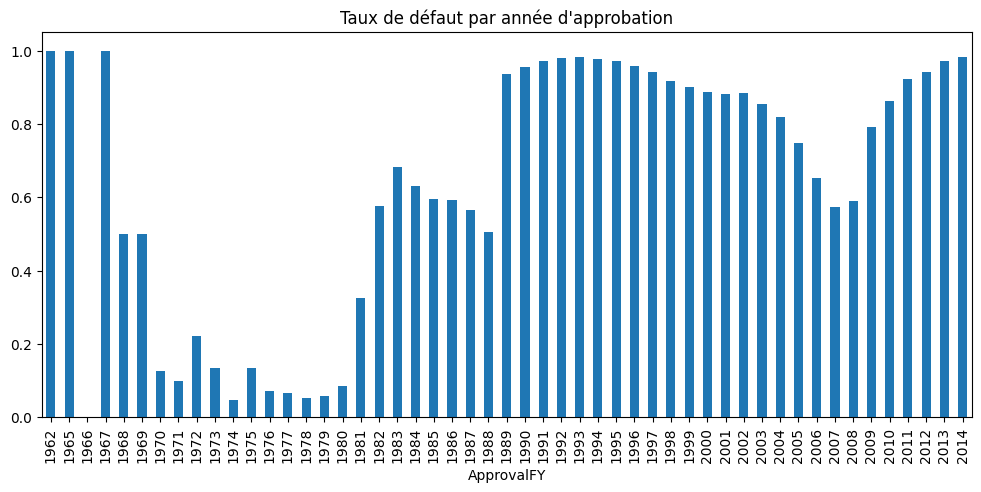

In [15]:
df.groupby("ApprovalFY")["MIS_Status"].mean().plot(kind="bar", figsize=(12, 5))
plt.title("Taux de défaut par année d'approbation")
plt.show()

In [16]:
# Séparation des variables explicatives et de la variable cible
#X = df.drop(columns=["MIS_Status", "State", "BankState"])  # Variables explicatives
#y = df["MIS_Status"]  # Variable cible
# Regrouper les États en clusters avec KMeans
# Convertir State et BankState en valeurs numériques (Label Encoding)

label_encoders = {}
for col in ["State", "BankState"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # On garde l'encodeur si besoin plus tard

print("Clusterssssssssssssssssssssssssssss000000000000")

# Appliquer KMeans pour regrouper State et BankState en clusters
for col in ["State", "BankState"]:
    kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)  # 10 clusters (modifiable)
    df[col + "_Cluster"] = kmeans.fit_predict(df[[col]])

print("Clusterssssssssssssssssssssssssssss")
#df = pd.get_dummies(df, columns=['Loan_Term_Category'], drop_first=False, dtype=int)

# Supprimer les colonnes originales State et BankState
X = df.drop(columns=["MIS_Status","State", "BankState"])#,"Term"
y = df["MIS_Status"]  # Variable cible

# Diviser les données en train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#scaler = StandardScaler() if normalisation_code == 1 else MaxAbsScaler()
#data_scaled = scaler.fit_transform(data)
#data = pd.DataFrame(data_scaled, columns=data.columns)

# Normalisation des données (centrer et réduire)
#scaler = StandardScaler()  # Ou vous pouvez choisir MinMaxScaler si nécessaire
# Normalisation des données
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Détection et suppression des outliers avec IsolationForest
"""iso_forest = IsolationForest(random_state=42)#contamination=0.05, 
outliers = iso_forest.fit_predict(X_train)
X_cleaned = X_train[outliers == 1]
y_cleaned = y_train[outliers == 1]"""

#model = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=15, random_state=42)
#model = AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
#from xgboost import XGBClassifier
#from sklearn.model_selection import GridSearchCV
################################################
execute_=False

if execute_:
    from sklearn.linear_model import SGDClassifier, LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.ensemble import VotingClassifier,AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
    from sklearn.metrics import classification_report


    model_1 = SGDClassifier(alpha=0.0001, average=False, class_weight=None, random_state=42, loss='log_loss')
    model_2 = DecisionTreeClassifier(random_state=42)
    model_3 = RandomForestClassifier(n_estimators=100, random_state=42)#probleme temps exécution avec KNeighborsClassifier(n_neighbors=2)
    model_4 = LogisticRegression(max_iter=1000, random_state=42)
    model_5 = AdaBoostClassifier(n_estimators=50, random_state=42)
    model_6 = GradientBoostingClassifier(n_estimators=100, random_state=42)
    model_7 = xgb.XGBClassifier(
            n_estimators=200,#200
            max_depth=10,
            learning_rate=0.1,#0.1
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss", 
        )

    """models = model_7
    models.fit(X_train_scaled, y_train)
    y_pred = models.predict(X_test_scaled)
    print(models.__class__.__name__)
    print(classification_report(y_test, y_pred))
    print(models.score(X_test_scaled, y_test))"""

    voting_model  = VotingClassifier(estimators=[
        ('sgd', model_1), 
        ('tree', model_2), 
        ('rf', model_3),
        ('lr', model_4),
        ('ada',model_5),
        ('gb',model_6),
        ('xgb',model_7),
    ], voting='soft')#hard

    for models in (model_1, model_2, model_3, model_4, model_5, model_6,model_7, voting_model ):
        models.fit(X_train_scaled, y_train)
        y_pred = models.predict(X_test_scaled)
        print(models.__class__.__name__)
        print(classification_report(y_test, y_pred))
        print(models.score(X_test_scaled, y_test))
    ####################################################


Clusterssssssssssssssssssssssssssss000000000000
Clusterssssssssssssssssssssssssssss


In [17]:
#pd.set_option('display.max_columns', 30)
#df.dtypes

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Fonction pour afficher le rapport détaillé des échantillons mal classifiés
def report_misclassifications(y_true, y_pred, classifier_name, n_examples=10):
    misclassified_idx = np.where(y_pred != y_true)[0]
    n_misclassified = len(misclassified_idx)
    
    print(f"\n--- Rapport détaillé des échantillons mal classifiés par {classifier_name} ---")
    print(f"Nombre total d'échantillons mal classifiés : {n_misclassified}")
    
    if n_misclassified > 0:
        uniques_true, counts_true = np.unique(y_true.iloc[misclassified_idx] if isinstance(y_true, pd.Series) else y_true[misclassified_idx], return_counts=True)
        print("Répartition (vrai label) :", dict(zip(uniques_true, counts_true)))
        
        uniques_pred, counts_pred = np.unique(y_pred.iloc[misclassified_idx] if isinstance(y_pred, pd.Series) else y_pred[misclassified_idx], return_counts=True)
        print("Répartition (prédiction) :", dict(zip(uniques_pred, counts_pred)))
        
        print(f"\nExemples (les {min(n_examples, n_misclassified)} premiers) :")
        for idx in misclassified_idx[:n_examples]:
            true_val = y_true.iloc[idx] if isinstance(y_true, pd.Series) else y_true[idx]
            pred_val = y_pred.iloc[idx] if isinstance(y_pred, pd.Series) else y_pred[idx]
            print(f"Index : {idx}, y_true : {true_val}, y_pred : {pred_val}")
    else:
        print("Aucun échantillon mal classifié.")

# -----------------------------
# Fonction pour sauvegarder les échantillons mal classifiés dans un fichier CSV
def save_misclassified_to_csv(y_true, y_pred, classifier_name, file_prefix="mispredicted_samples_"):
    # Obtenir les indices des échantillons mal classifiés
    misclassified_idx = np.where(y_pred != y_true)[0]
    # Utiliser .iloc si y_true (et y_pred) est une Series
    true_vals = y_true.iloc[misclassified_idx] if isinstance(y_true, pd.Series) else y_true[misclassified_idx]
    pred_vals = y_pred.iloc[misclassified_idx] if isinstance(y_pred, pd.Series) else y_pred[misclassified_idx]
    
    data = {
        "Index": misclassified_idx,
        "y_true": true_vals,
        "y_pred": pred_vals
    }
    df = pd.DataFrame(data)
    filename = f"{file_prefix}{classifier_name}.csv"
    df.to_csv(filename, index=False)
    print(f"Fichier CSV généré pour {classifier_name} : {filename}")

# -----------------------------
# 1. Définir les classifieurs
clf_logreg = LogisticRegression(max_iter=1000, random_state=42)
clf_xgb    = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

classifiers = [clf_logreg, clf_xgb]
classifier_names = ['LogReg', 'XGB']

# -----------------------------
# 2. Calcul des poids en fonction du f1-score (global) via validation croisée
chosen_metric = "f1"  # Vous pouvez changer ici la métrique choisie

print(f"Calcul des poids ({chosen_metric} moyen) pour chaque classifieur :")
weights = {}
for name, clf in zip(classifier_names, classifiers):
    start_time = time.time()
    print(f"Calcul du {chosen_metric} pour {name}...")
    score = cross_val_score(clf, X_train_scaled, y_train, cv=5, scoring=chosen_metric).mean()
    weights[name] = score
    elapsed_time = time.time() - start_time
    print(f"Temps d'exécution pour {name} : {elapsed_time:.2f} secondes")

print(f"\nPoids ({chosen_metric} moyens) :", weights)

# -----------------------------
# 3. Entraînement des classifieurs
print("\nEntraînement des classifieurs :")
for name, clf in zip(classifier_names, classifiers):
    start_time = time.time()
    print(f"Entraînement de {name}...")
    clf.fit(X_train_scaled, y_train)
    elapsed_time = time.time() - start_time
    print(f"Temps d'entraînement pour {name} : {elapsed_time:.2f} secondes")

# -----------------------------
# 4. Évaluation individuelle de chaque classifieur sur le jeu de test
print("\nÉvaluation individuelle sur le jeu de test :")
predictions = {}  # Pour stocker les prédictions de chaque classifieur
for name, clf in zip(classifier_names, classifiers):
    pred = clf.predict(X_test_scaled)
    predictions[name] = pred
    print(f"\n--- Rapport de classification pour {name} ---")
    print(classification_report(y_test, pred))
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision :", precision_score(y_test, pred))
    print("Recall :", recall_score(y_test, pred))
    print("F1-score :", f1_score(y_test, pred))
    
    # Affichage du rapport détaillé sur les échantillons mal classifiés
    report_misclassifications(y_test, pred, name)
    # Sauvegarde dans un fichier CSV
    save_misclassified_to_csv(y_test, pred, name)

# -----------------------------
# 5. Calcul de l'ensemble par agrégation pondérée
print("\nCalcul des probabilités prédites pour l'ensemble (agrégation pondérée) :")
probs = []
for name, clf in zip(classifier_names, classifiers):
    start_time = time.time()
    prob = clf.predict_proba(X_test_scaled)[:, 1]
    probs.append(prob)
    elapsed_time = time.time() - start_time
    print(f"Temps de prédiction pour {name} : {elapsed_time:.2f} secondes")
    
probs = np.array(probs)

weight_vector = np.array([weights[name] for name in classifier_names])
if weight_vector.sum() == 0:
    weight_vector = np.ones_like(weight_vector) / len(weight_vector)
else:
    weight_vector = weight_vector / weight_vector.sum()
print(f"\nVecteur de poids normalisés ({chosen_metric}) :", weight_vector)

start_time = time.time()
final_prob = np.average(probs, axis=0, weights=weight_vector)
elapsed_time = time.time() - start_time
print(f"Temps de calcul des probabilités pondérées : {elapsed_time:.2f} secondes")

# -----------------------------
# 6. Binarisation des prédictions finales (seuil = 0.5)
threshold = 0.6  # Seuil de binarisation
start_time = time.time()
final_pred = (final_prob >= threshold).astype(int)
elapsed_time = time.time() - start_time
print(f"Temps de binarisation des prédictions finales : {elapsed_time:.2f} secondes")

# -----------------------------
# 7. Affichage des performances de l'ensemble
print("\n--- Rapport de classification pour l'ensemble (agrégation pondérée) ---")
print(classification_report(y_test, final_pred))
print("Accuracy :", accuracy_score(y_test, final_pred))
print("Precision :", precision_score(y_test, final_pred))
print("Recall :", recall_score(y_test, final_pred))
print("F1-score :", f1_score(y_test, final_pred))

# Rapport détaillé et sauvegarde des échantillons mal classifiés par l'ensemble
report_misclassifications(y_test, final_pred, "Ensemble")
save_misclassified_to_csv(y_test, final_pred, "Ensemble")


Calcul des poids (f1 moyen) pour chaque classifieur :
Calcul du f1 pour LogReg...
Temps d'exécution pour LogReg : 13.63 secondes
Calcul du f1 pour XGB...


c:\Users\asus\OneDrive\Bureau\Formations\USSBA_Classification\Brief04_USSBA_classification\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:53:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\asus\OneDrive\Bureau\Formations\USSBA_Classification\Brief04_USSBA_classification\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:53:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\asus\OneDrive\Bureau\Formations\USSBA_Classification\Brief04_USSBA_classification\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:53:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-a

In [19]:
"""param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False,
)

model = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',  # ou 'accuracy' selon votre objectif
    cv=5,
    verbose=1,
    n_jobs=-1  # utiliser tous les cœurs disponibles
)"""
##################################################################
"""model = xgb.XGBClassifier(
        n_estimators=200,#200
        max_depth=10,
        learning_rate=0.1,#0.1
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss", 
    )"""
################################################################
"""xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,  # Important pour éviter les warnings et erreurs
    eval_metric="logloss"
)
rf_model = RandomForestClassifier(random_state=42)
lr_model = LogisticRegression(random_state=42)

# Créer le VotingClassifier
ensemble_model = VotingClassifier(estimators=[
    ('xgb', xgb_model),
    ('rf', rf_model),
    ('lr', lr_model)
], voting='soft')"""

#smote = SMOTE(random_state=42)
#X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train) --> 94% avec 20 mn entrainement

'xgb_model = xgb.XGBClassifier(\n    random_state=42,\n    use_label_encoder=False,  # Important pour éviter les warnings et erreurs\n    eval_metric="logloss"\n)\nrf_model = RandomForestClassifier(random_state=42)\nlr_model = LogisticRegression(random_state=42)\n\n# Créer le VotingClassifier\nensemble_model = VotingClassifier(estimators=[\n    (\'xgb\', xgb_model),\n    (\'rf\', rf_model),\n    (\'lr\', lr_model)\n], voting=\'soft\')'

In [ ]:
ensemble_model = model

ensemble_model.fit(X_train, y_train)

# Apprendre le modèle
#model = LogisticRegression(max_iter=6000)
#model.fit(X_train_scaled, y_train)  # Utiliser X_train_scaled pour l'entraînement

# Prédiction
y_pred = ensemble_model.predict(X_test)  # Utiliser X_test_scaled pour la prédiction

# Évaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


# Il faut voir les valeurs Nan et leurs significations et impacts sur le modèle
# Il faut voir l'impact des valeurs outliers ISOLATION FOREST

# Vérifier l'importance des features
importances = ensemble_model.feature_importances_
features = X_train.columns

# Affichage des features les plus importantes
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=features)
plt.title("Importance des Features")
plt.show()